it is file path

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv


In [3]:
df=pd.read_csv('/kaggle/input/datasets/rjmanoj/credit-card-customer-churn-prediction/Churn_Modelling.csv')

In [6]:
df.head()
#print(df.shape)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Exited'].value_counts

<bound method IndexOpsMixin.value_counts of 0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64>

In [10]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [12]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [13]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [14]:
df.drop(columns=['RowNumber','CustomerId','Surname'],inplace=True)

In [15]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [17]:
df.shape

(10000, 11)

In [43]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True)

In [44]:
df

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [46]:
X=df.drop(columns=['Exited'])
y=df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=1)

In [47]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [48]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [49]:
X.shape

(10000, 11)

In [50]:
X_train

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
2694,628,29,3,113146.98,2,0,1,124749.08,True,False,True
5140,626,29,4,105767.28,2,0,0,41104.82,False,False,False
2568,612,47,6,130024.87,1,1,1,45750.21,True,False,False
3671,646,52,6,111739.40,2,0,1,68367.18,True,False,False
7427,714,33,8,122017.19,1,0,0,162515.17,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...
2895,621,47,7,107363.29,1,1,1,66799.28,True,False,True
7813,684,63,3,81245.79,1,1,0,69643.31,True,False,False
905,672,45,9,0.00,1,1,1,92027.69,False,False,False
5192,663,39,8,0.00,2,1,1,101168.90,False,False,False


In [51]:
X_train.shape

(8000, 11)

In [56]:
X_test.shape

(2000, 11)

In [53]:
y_train.shape

(8000,)

In [54]:
y_test.shape

(2000,)

In [55]:
y_train.shape

(8000,)

In [57]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [58]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]])

every array is customer and we have scaled all value very small

In [60]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense



MODEL BUILDING

In [81]:
model=Sequential()  # making object of sequential as model
                        # add layers , input , hidden , output layer , for hidden layer we will use 3 perceptrons , nodes
model.add(Dense(11,activation='relu',input_dim=11)) 
model.add(Dense(11,activation='relu')) #hidden layer 11 columns in input 
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [82]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [84]:
# COMPILING MODEL GIVING INFO OF LOSS FUNCTION AND OPTIMIZER  accuracy will also be shown after each epochs
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [93]:
# FIT MODEL  finding weight and bias and epoch is basically how many times loop run for training
history=model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)    # loss is getting reduced as we are training for the weights and bias  validation .2 means 20% pe nahi chalega
# NOW OUR MODEL IS TRAINED 

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8664 - loss: 0.3219 - val_accuracy: 0.8550 - val_loss: 0.3439
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8677 - loss: 0.3220 - val_accuracy: 0.8556 - val_loss: 0.3424
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8680 - loss: 0.3218 - val_accuracy: 0.8512 - val_loss: 0.3451
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8689 - loss: 0.3212 - val_accuracy: 0.8531 - val_loss: 0.3438
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8677 - loss: 0.3213 - val_accuracy: 0.8581 - val_loss: 0.3461
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8666 - loss: 0.3216 - val_accuracy: 0.8525 - val_loss: 0.3433
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8662 - loss: 0.3220 - val_accuracy: 0.8544 - val_loss: 0.3445
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8672 - loss: 0.3211 - val_accu

In [86]:
# where weights and bias are stored 
model.layers[0].get_weights()  # get all weights and bias for layer 1 hidden layer generated by this

[array([[-0.07070476,  0.03380531,  0.20724627,  0.00923615,  0.666429  ,
         -0.10869469, -0.16205856, -0.06174665, -0.50140274, -0.06217829,
         -0.01772667],
        [-0.3760335 ,  0.29425138,  1.2839353 , -0.13472484,  0.19544968,
          1.1083608 ,  0.14023273, -0.32337555, -0.04155972,  0.78589135,
          0.03853748],
        [ 0.07283402, -0.04383243, -0.12648642, -0.15075684, -0.11202549,
         -0.0894037 , -0.02915739,  0.11136068, -0.5093444 ,  0.08445978,
         -0.11558194],
        [-0.39527768, -0.28270695,  0.19274718,  0.30389035,  0.04624074,
         -0.3674199 ,  0.33126473, -0.15516628,  0.22956109,  0.02659578,
          0.7649264 ],
        [-0.28202528,  0.20145874,  0.8119528 ,  0.25876075, -0.27278283,
         -0.8882967 ,  1.0760329 ,  0.42166033, -0.12738313,  0.14157206,
         -0.15140544],
        [-0.31652892, -0.3277948 , -0.17936997, -0.35900357,  0.01494638,
         -0.13972634,  0.03722324,  0.59334415,  0.09934416,  0.1526548

In [87]:
model.layers[1].get_weights()   # weight and bias associated with the output layer  

[array([[ 2.3294295e-01,  1.3717566e-01, -3.3323556e-01,  3.5546690e-01,
          1.8893939e-01,  3.9153713e-01,  3.4137633e-01,  3.4867921e-01,
         -1.9044660e-01, -1.9431685e-01,  6.2310058e-01],
        [ 3.4195945e-01,  3.0103174e-01,  4.4838721e-01,  3.2890511e-01,
         -4.0293017e-01,  3.3912149e-03,  6.9894934e-01, -3.4292397e-01,
          6.1987698e-02, -6.2317187e-01,  2.5295082e-02],
        [ 2.5889340e-01, -6.6191518e-01,  3.9503209e-02, -7.4275569e-03,
         -8.3687592e-01,  3.9560059e-01, -1.5041865e-01,  7.3619694e-01,
         -4.7265840e-01,  5.9082681e-01, -5.5045694e-01],
        [ 3.2528883e-01, -2.9590788e-01, -1.8780665e-01,  2.9272783e-01,
          3.4439439e-01,  5.0751579e-01,  3.7243807e-01, -4.6516847e-02,
          6.9749224e-01, -6.4479274e-01, -1.1146660e-01],
        [ 1.0894217e-02,  2.1889949e-01,  2.2102208e-01,  5.2865905e-01,
          4.9258825e-01,  1.2290646e-02, -2.9538563e-01,  5.3232330e-01,
          6.6214389e-01, -3.5470834e-0

In [88]:
# now model is ready for the prediction
y_log=model.predict(X_test_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


output is not 0/1 it is between 0 and 1 because we are using sigmoid and sigmoid gives probability to succeed 

In [90]:
# if want to get the exact 0/1 then use threshhold like above threshhold pass and below or equal fail and can get this threshhold by some auc roc bla bla bla 
y_pred=np.where(y_log>0.5,1,0)

In [91]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]])

In [92]:
# checking accuracy of model
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.864

In [95]:
import matplotlib.pyplot as plt

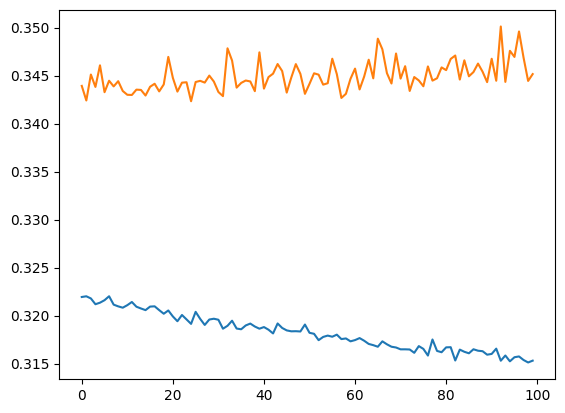

In [99]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

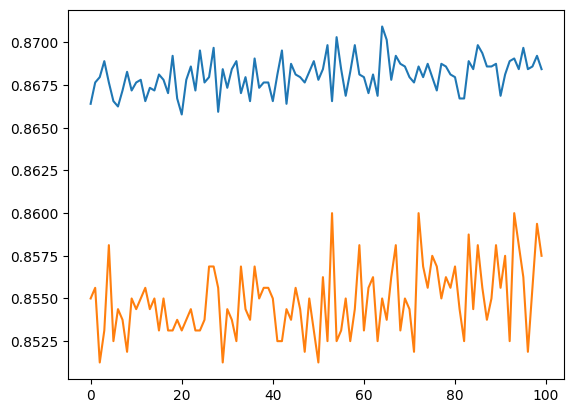

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [96]:
history

In [97]:
history.history

{'accuracy': [0.866406261920929,
  0.8676562309265137,
  0.867968738079071,
  0.8689062595367432,
  0.8676562309265137,
  0.8665624856948853,
  0.8662499785423279,
  0.8671875,
  0.8682812452316284,
  0.8671875,
  0.8676562309265137,
  0.8678125143051147,
  0.8665624856948853,
  0.8673437237739563,
  0.8671875,
  0.8681250214576721,
  0.8678125143051147,
  0.8670312762260437,
  0.8692187666893005,
  0.8667187690734863,
  0.8657812476158142,
  0.8678125143051147,
  0.8685937523841858,
  0.8671875,
  0.8695312738418579,
  0.8676562309265137,
  0.867968738079071,
  0.8696874976158142,
  0.8659374713897705,
  0.8684375286102295,
  0.8673437237739563,
  0.8684375286102295,
  0.8689062595367432,
  0.8670312762260437,
  0.867968738079071,
  0.8665624856948853,
  0.8690624833106995,
  0.8673437237739563,
  0.8676562309265137,
  0.8676562309265137,
  0.8665624856948853,
  0.8681250214576721,
  0.8695312738418579,
  0.866406261920929,
  0.8687499761581421,
  0.8681250214576721,
  0.8679687380790